# Game of Science: Agent Similarity Analysis

This notebook analyzes the similarity between the RL agent and the fixed archetypes (careerist, orthodox scientist, mass producer) by comparing their action-feature vectors.

## Methodology
Instead of comparing raw action integers, we construct a semantically meaningful feature vector for each agent at each timestep using both action and observation data. The vector includes:
- **Project Choice**: Binary choice, required effort, prestige, novelty, and time window.
- **Collaboration**: Number of collaborators, mean reputation of partners, and mean distance to partners.
- **Effort Allocation**: Effort target features (prestige, novelty, effort, fit, etc.).

We then compute Euclidean Distance and Cosine Similarity between the RL agent and all other agents, grouped by archetype.


In [3]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import importlib

# Ensure project root is in sys.path when running from notebooks folder
if Path.cwd().name == 'notebooks':
    os.chdir('..')

from analysis.analyze_agent_similarity import *


## Run Analysis
Specify the paths to your log files and rolling window.
A larger rolling window (e.g., 20) results in smoother plots.


In [4]:
ACTIONS_FILE = "test_results/rl_ppo_by_effort_s501_20260427_201740_s501/rl_ppo_by_effort_s501_actions.jsonl"
OBS_FILE = "test_results/rl_ppo_by_effort_s501_20260427_201740_s501/rl_ppo_by_effort_s501_observations.jsonl"
OUTPUT_PREFIX = "log/similarity_s101"
ROLLING_WINDOW = 50

main(ACTIONS_FILE, OBS_FILE, OUTPUT_PREFIX, rolling_window=ROLLING_WINDOW)


Loading data from test_results/rl_ppo_by_effort_s501_20260427_201740_s501/rl_ppo_by_effort_s501_actions.jsonl and test_results/rl_ppo_by_effort_s501_20260427_201740_s501/rl_ppo_by_effort_s501_observations.jsonl...
Processing 600 timesteps...
Computing similarities...

Overall Summary:
            archetype  overall_mean_euclidean  overall_mean_cosine  \
0           careerist               44.443512             0.518309   
1       mass_producer               41.963303             0.595873   
2  orthodox_scientist               46.014802             0.501094   

   n_comparisons  
0          10975  
1          30265  
2          11228  

Generating plots...
Analysis complete. Results saved with prefix: log/similarity_s101


## Results Visualization


Overall Similarity Summary:


,archetype,overall_mean_euclidean,overall_mean_cosine,n_comparisons
0,careerist,44.443512,0.518309,10975
1,mass_producer,41.963303,0.595873,30265
2,orthodox_scientist,46.014802,0.501094,11228



Cosine Similarity (Rolling Average):


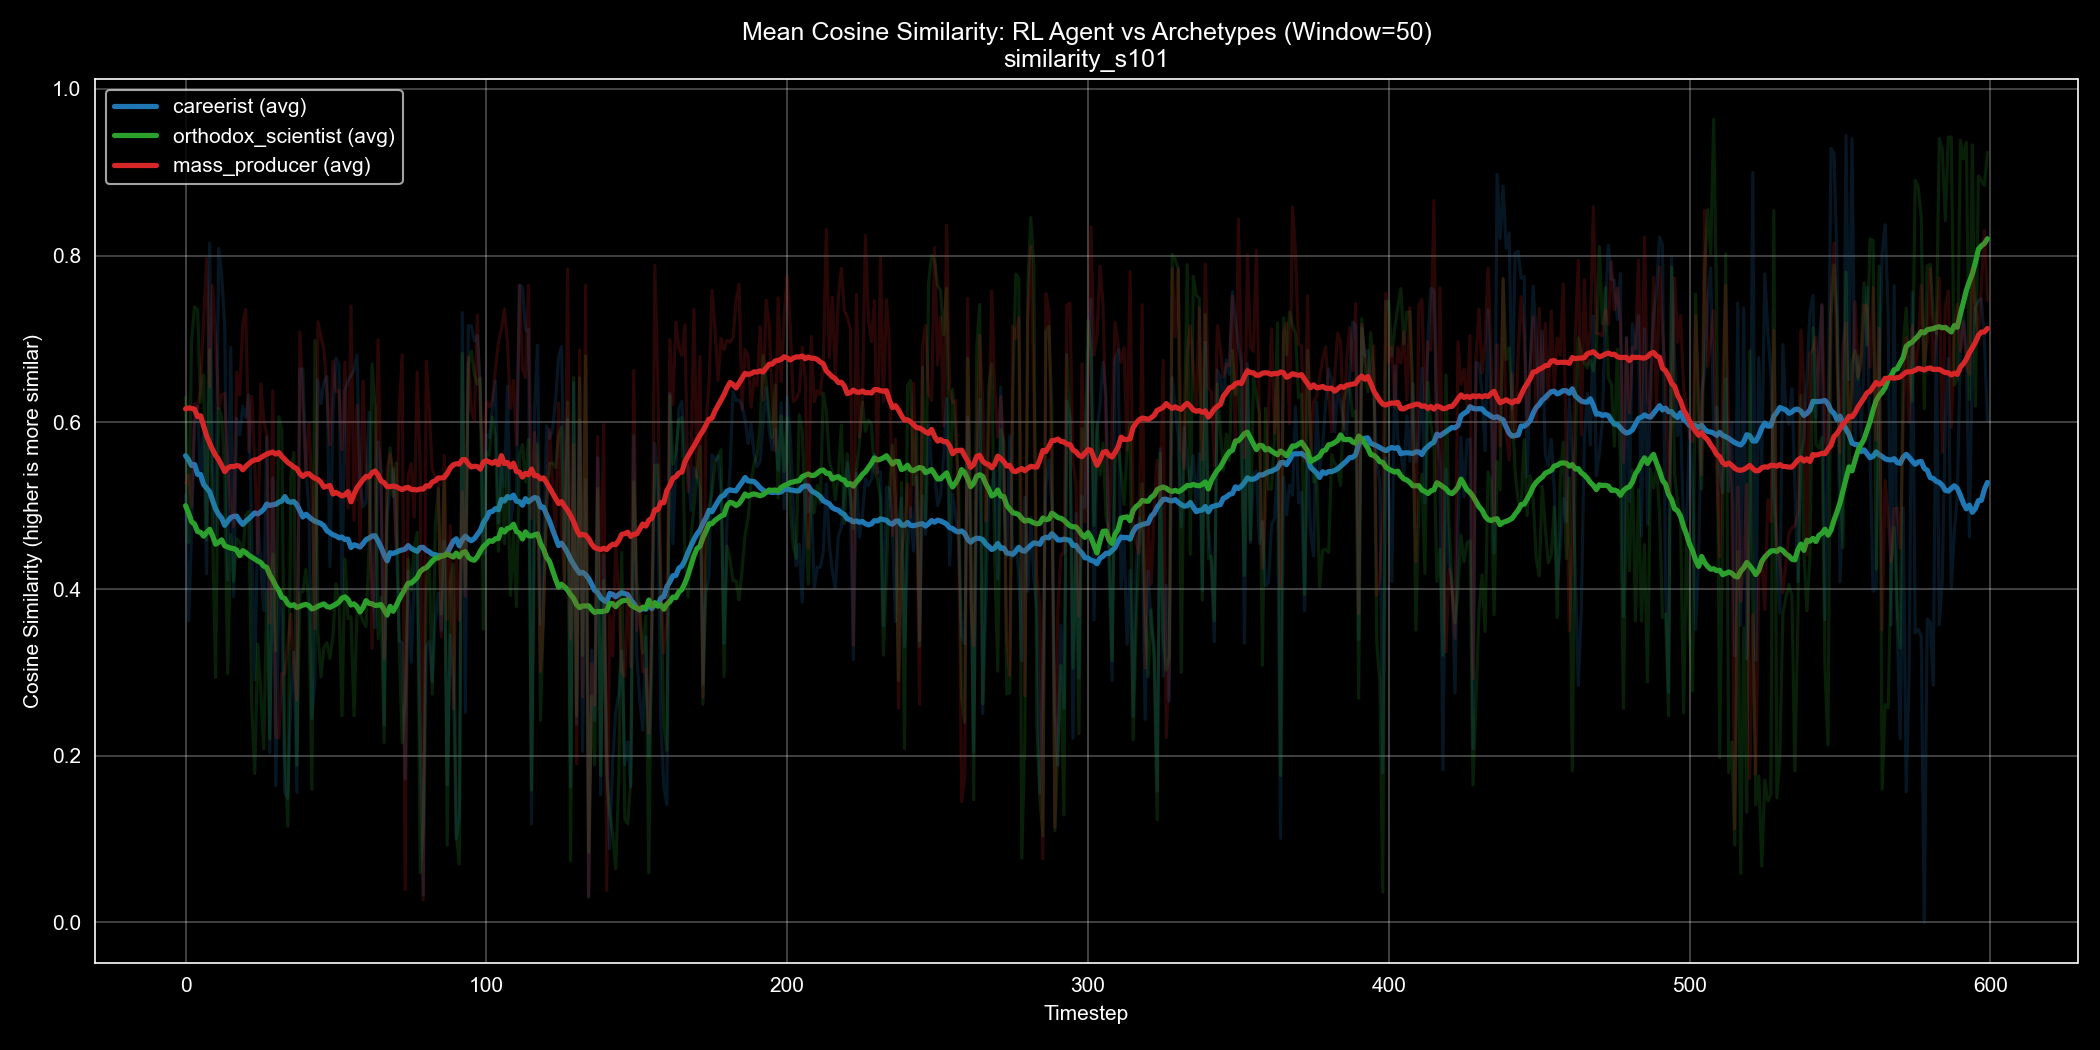


Cosine Similarity Distribution:


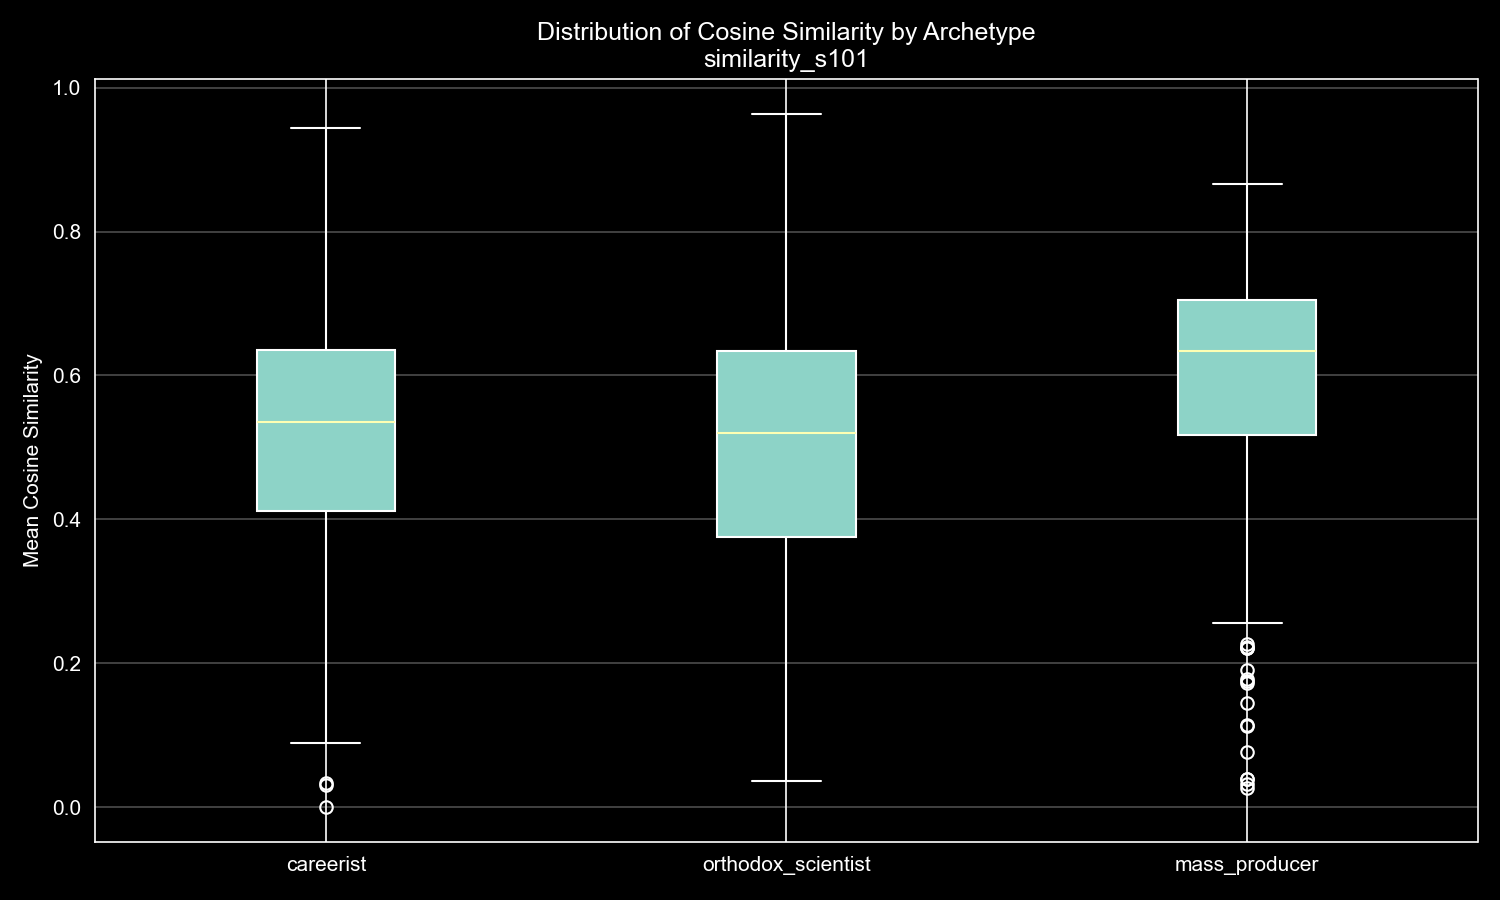

In [5]:
summary_df = pd.read_csv(f"{OUTPUT_PREFIX}_summary.csv")
print("Overall Similarity Summary:")
display(summary_df)

# Show the generated plots
from IPython.display import Image, display as display_img

print("\nCosine Similarity (Rolling Average):")
display_img(Image(filename=f"results/{Path(OUTPUT_PREFIX).name}_cosine_similarity.png"))

print("\nCosine Similarity Distribution:")
display_img(Image(filename=f"results/{Path(OUTPUT_PREFIX).name}_cosine_distribution.png"))
